# Data Preprocessing 01 - Handling Missing Data

> **MLCourse · Data Science Foundations · 05_data_preprocessing**

Real datasets arrive with holes. Surveys go unanswered, sensors glitch, customers
refuse to type their age into a form. Before a single model can be trained, you need
a principled way to *detect*, *understand* and *repair* those holes - and the
discipline to repair them without leaking test-set information.

This notebook pairs every technique in two versions: **manual pandas/NumPy** (so you
see exactly what happens) and its **scikit-learn equivalent** (so it slots into
production pipelines). The fit/transform paradigm is introduced properly here and
reused for the rest of the preprocessing track.

## What you'll learn

- Why missing data breaks models, and pandas' quirky NaN semantics (`nan != nan`)
- The MCAR / MAR / MNAR theory - and why the mechanism dictates your strategy
- Detection tools: counts, percentages and a missingno-style nullity matrix (no extra libraries)
- When row/column deletion is safe vs dangerous
- Imputation: sentinel values, mean vs median on skewed data, mode, ffill/bfill
- Group-wise imputation with `groupby` + `transform` (and proof that it beats global fills)
- Model-based imputation intuition via `KNNImputer`
- `SimpleImputer`, the fit/transform paradigm, and THE data-leakage trap

In [1]:
try:  # same effect as typing "%matplotlib inline" in Jupyter; safe as plain script
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_theme(style="whitegrid")

## 1. Why missing data breaks models - and pandas' NaN semantics

**What's happening:** scikit-learn estimators do linear algebra on NumPy arrays, and
almost any formula containing `NaN` propagates it (`NaN + 5 = NaN`). So most
estimators refuse outright: `ValueError: Input contains NaN`. Pandas, by contrast,
is *polite*: aggregations silently skip NaN. Convenient when exploring, dangerous
when modeling - the politeness hides how much information is actually gone.

**Why this matters:** you must be able to *see* NaN clearly before deciding what to
do with it. Two quirks to internalize right now:

1. `NaN` is never equal to anything, including itself → equality tests fail; use `isna()`.
2. Pandas sums/means skip NaN by default (`skipna=True`) → a "total" may quietly
   cover fewer observations than you think.

In [2]:
nan_value = np.nan

print("nan != nan        :", nan_value != nan_value)   # True! equality is useless
print("None == None      :", None == None)             # True (None is a real object)
print("detect with isna():", pd.isna(nan_value))       # True - always detect, never compare

demo_sums = pd.Series({"a": 10.0, "b": np.nan, "c": 30.0})
print("\nSeries with one NaN:", demo_sums.to_dict())
print("sum()              :", demo_sums.sum(),       "<- NaN silently skipped")
print("sum(skipna=False)  :", demo_sums.sum(skipna=False), "<- NaN poisons the result")
print("count() (non-NaN)  :", demo_sums.count(),     "<- how many values REALLY contributed")

# dtype side-effects: a single NaN forces int -> float
ints_with_hole = pd.Series([1, 2, np.nan, 4])
print("\ndtype after one NaN sneaks in:", ints_with_hole.dtype)

nan != nan        : True
None == None      : True
detect with isna(): True

Series with one NaN: {'a': 10.0, 'b': nan, 'c': 30.0}
sum()              : 40.0 <- NaN silently skipped
sum(skipna=False)  : nan <- NaN poisons the result
count() (non-NaN)  : 2 <- how many values REALLY contributed

dtype after one NaN sneaks in: float64


> ⚠️ **Common pitfall:** Filtering with `df[df.col == np.nan]` returns *nothing*
> because nothing equals NaN. Use `df[df.col.isna()]`.

## 2. THE THEORY: MCAR vs MAR vs MNAR

**What:** Statisticians split missingness into three mechanisms. Knowing which one
you face is not academic hair-splitting - it literally determines whether deletion is
safe and which imputation can work.

| Mechanism | Probability of a gap depends on... | Relatable example |
|---|---|---|
| **MCAR** - Missing Completely At Random | nothing at all | A scanner randomly failed on 3% of paper forms |
| **MAR** - Missing At Random | other columns you STILL HAVE | Third-class passengers' ages are poorly documented; online users who sign up by phone skip the age field |
| **MNAR** - Missing Not At Random | the hidden value itself | People with very high incomes refuse to report them |

**Why it dictates strategy:**

- **MCAR** → the observed rows remain an unbiased sample, so dropping rows is
  statistically harmless if few (< ~5%). Any imputation is also unbiased.
- **MAR** → deletion *biases* your sample (e.g., dropping unknown ages deletes
  third-class passengers). But the good news: since the gap is explained by columns
  you have, those columns can predict the fill value - group-wise / model-based
  imputation shines here.
- **MNAR** → nothing fully repairs what the data refuses to tell you. Median beats
  mean (robust to the distortion), and honesty about limitations beats bravado.

Practical triage question: *"Can I explain the gaps using columns I still have?"*

## 3. Building a deliberately-missing demo frame

**What:** We derive a small Titanic passenger table and punch three different kinds
of holes into it, each engineered to follow one of the three mechanisms:

- `embarked` → **MCAR**: random boarding-record glitches (~8%).
- `age`      → **MAR**: 3rd-class records are badly kept (45% missing there, only
               10% elsewhere) - missingness explained by an *observed* column.
- `fare`     → **MNAR**: expensive fares were under-reported (top 15% of fares
               vanish) - missingness depends on the value itself.

We keep pristine copies of age/fare aside so we can later measure how well each
repair strategy recovers the truth.

In [3]:
def make_titanic_like(n=600):
    """Offline stand-in with realistic titanic-like joint structure."""
    rng = np.random.default_rng(7)
    pclass = rng.choice([1, 2, 3], size=n, p=[0.25, 0.22, 0.53])
    sex = rng.choice(["male", "female"], size=n, p=[0.64, 0.36])
    age_mu = (
        np.where(sex == "female", 27.0, 31.0)
        - np.where(pclass == 1, 4.0, 0.0)
        + np.where(pclass == 3, 3.0, 0.0)
    )
    age = np.clip(rng.normal(age_mu, 9.0), 1.0, 80.0)
    fare_mu = np.where(pclass == 1, np.log(85.0), np.where(pclass == 2, np.log(22.0), np.log(9.5)))
    fare = rng.lognormal(fare_mu, 0.6)
    embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09])
    return pd.DataFrame(
        {"pclass": pclass, "sex": sex, "age": age.round(1),
         "fare": fare.round(2), "embarked": embarked}
    )


try:  # prefer the real thing when the seaborn sample is available
    base = sns.load_dataset("titanic")[["pclass", "sex", "age", "fare", "embarked"]].dropna()
    base = base.sample(n=400, random_state=42).reset_index(drop=True)
    DATA_SOURCE = "seaborn titanic"
except Exception:
    base = make_titanic_like()
    DATA_SOURCE = "synthetic titanic-like"

demo = base.copy()
demo["true_age"] = demo["age"]      # ground truth parked aside for evaluation
demo["true_fare"] = demo["fare"]

rng = np.random.default_rng(42)

# --- MCAR on 'embarked': uniform random record loss -------------------------
mcar_mask = rng.random(len(demo)) < 0.08
demo.loc[mcar_mask, "embarked"] = np.nan

# --- MAR on 'age': gaps depend on OBSERVED pclass ---------------------------
mar_prob = np.where(demo["pclass"] == 3, 0.45, 0.10)
mar_mask = rng.random(len(demo)) < mar_prob
demo.loc[mar_mask, "age"] = np.nan

# --- MNAR on 'fare': top-15% fares hide themselves --------------------------
fare_cut = demo["true_fare"].quantile(0.85)
mnar_mask = demo["true_fare"] >= fare_cut
demo.loc[mnar_mask, "fare"] = np.nan

# a realistic mostly-empty column, like titanic's 'deck' (~77% missing)
note_vals = rng.choice(["ok", "check", "urgent"], size=len(demo))
# object dtype + None keeps this a true STRING column with real holes
demo["inspector_note"] = pd.Series(
    np.where(rng.random(len(demo)) < 0.80, None, note_vals),
    index=demo.index,
    dtype="object",
)

print(f"data source: {DATA_SOURCE} | rows: {len(demo)}")
demo.head()

data source: seaborn titanic | rows: 400


,pclass,sex,age,fare,embarked,true_age,true_fare,inspector_note
0,1,female,24.0,NaN,C,24.0,69.3000,None
1,1,female,54.0,NaN,C,54.0,78.2667,None
2,1,male,52.0,NaN,S,52.0,79.6500,None
3,1,female,18.0,NaN,C,18.0,262.3750,None
4,2,male,27.0,26.0,S,27.0,26.0000,None


## 4. Detection: making the invisible visible

**What:** Two complementary views of missingness:

- a **table** - exact counts and percentages per column (your triage sheet);
- a **nullity matrix** - every cell drawn black if missing. Human eyes catch
  *patterns* (bands, blocks, correlations between gaps) far better than they read
  numbers. The popular `missingno` library draws exactly this; we build it from
  scratch with `plt.imshow(df.isna())` - no extra dependency needed.

In [4]:
def missing_report(df):
    """Absolute + percentage missing per column, worst offenders first."""
    report = pd.DataFrame(
        {"n_missing": df.isna().sum(),
         "pct_missing": (df.isna().mean() * 100).round(1)}
    )
    return report.sort_values("pct_missing", ascending=False)

missing_report(demo)

,n_missing,pct_missing
inspector_note,314,78.5
age,110,27.5
fare,60,15.0
embarked,22,5.5
pclass,0,0.0
sex,0,0.0
true_age,0,0.0
true_fare,0,0.0


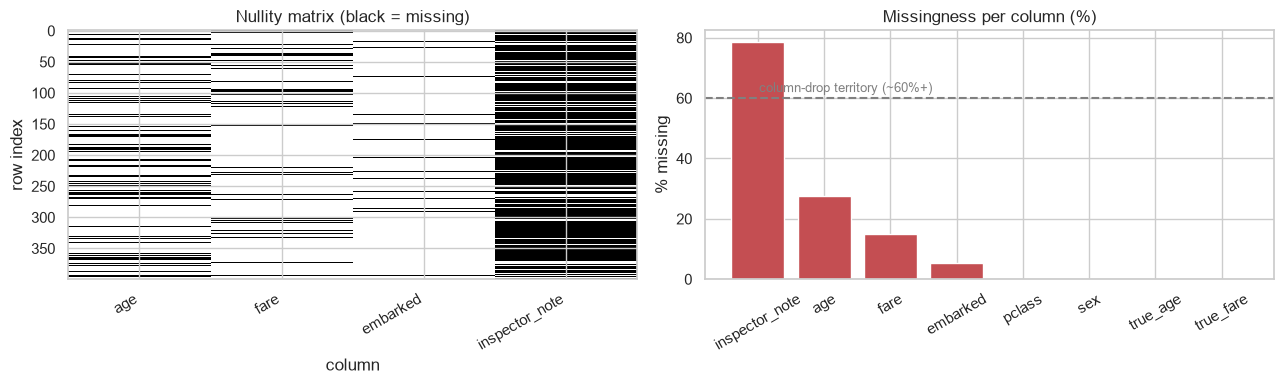

In [5]:
cols = ["age", "fare", "embarked", "inspector_note"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(demo[cols].isna().values, aspect="auto", cmap="Greys", interpolation="nearest")
axes[0].set_title("Nullity matrix (black = missing)")
axes[0].set_xlabel("column")
axes[0].set_ylabel("row index")
axes[0].set_xticks(range(len(cols)))
axes[0].set_xticklabels(cols, rotation=30, ha="right")

pct = missing_report(demo)["pct_missing"]
axes[1].bar(pct.index, pct.values, color="#c44e52")
axes[1].axhline(60, ls="--", c="gray")
axes[1].text(0.02, 62, "column-drop territory (~60%+)", fontsize=9, color="gray")
axes[1].set_title("Missingness per column (%)")
axes[1].set_ylabel("% missing")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Read the matrix: the `inspector_note` band is nearly solid black (drop candidate),
`age` shows a blocky pattern concentrated in certain row groups (that is MAR - the
third-class rows), while `embarked` speckles randomly (MCAR).

> 💡 **Pro tip:** Sort rows by a suspect column (`demo.sort_values("fare")`) and
> re-draw the matrix. If gaps line up with another column's values, MAR just
> introduced itself.

## 5. Deletion: simple, fast, sometimes wrong

**What:** `dropna()` removes rows or columns with gaps. Variants matter:

- `how="any"` (default) drops a row if ANY selected cell is missing;
- `subset=[...]` restricts which columns are checked;
- `thresh=k` keeps rows having at least k observed values;
- dropping whole **columns** fits when a variable is mostly empty AND low-value
  (Titanic's `deck`: ~77% missing - reconstruction would be fiction).

**Why care:** row deletion compounds across columns. Each column's gaps kill rows
independently, so three mildly-gappy columns can wipe out a huge share of data -
let's measure it rather than guess.

In [6]:
work = demo[["pclass", "sex", "age", "fare", "embarked"]].copy()
n0 = len(work)

any_drop = work.dropna()                                   # how="any" default
print(f"rows: {n0} -> {len(any_drop)}  ({len(any_drop)/n0:.0%} survive naive dropna)")

sub_drop = work.dropna(subset=["embarked"])                # only guard ONE column
print(f"dropna(subset=['embarked'])     : {len(sub_drop)} rows survive "
      f"({len(sub_drop)/n0:.0%})")

thr_drop = work.dropna(thresh=len(work.columns) - 1)       # allow at most 1 gap/row
print(f"dropna(thresh={len(work.columns)-1})            : {len(thr_drop)} rows survive")

# column-level rule: mostly empty AND low value
note_pct = demo["inspector_note"].isna().mean()
if note_pct > 0.60:
    print(f"\n'inspector_note' is {note_pct:.0%} missing and low-value -> DROP the column")
lean = demo.drop(columns=["inspector_note"])
print("columns now:", list(lean.columns))

rows: 400 -> 223  (56% survive naive dropna)
dropna(subset=['embarked'])     : 378 rows survive (94%)
dropna(thresh=4)            : 386 rows survive

'inspector_note' is 78% missing and low-value -> DROP the column
columns now: ['pclass', 'sex', 'age', 'fare', 'embarked', 'true_age', 'true_fare']


Naive `dropna()` just vaporized ~half our rows - and under MAR it would also bias
whoever survives (third-class passengers disproportionately gone). Deletion is a
scalpel for MCAR nicks, not a default policy.

> ⚠️ **Common pitfall:** `df.dropna()` typed reflexively at the top of a script.
> Always print before/after row counts and ask *who* got deleted - the answer may
> be "exactly the people my model needs".

## 6. Imputation I: quick fills

### 6a. Constant sentinel

**What:** replace gaps with an explicit placeholder - `"Unknown"` for categoricals,
a distinct number for trees-only workflows.

**Why:** "value absent" is often *informative itself* (an unlisted embarkation port
is a fact about the passenger). Sentinel keeps that signal visible instead of
pretending we guessed the truth.

In [7]:
sent = lean.copy()

sent["embarked_filled"] = sent["embarked"].fillna("Unknown")
print(sent["embarked_filled"].value_counts())

# numeric sentinel anti-pattern preview (fine for trees, poison for means/distances):
tmp_mean = sent["fare"].fillna(-1).mean()
print(f"\nfare mean after -1 sentinel fill: {tmp_mean:,.2f}  <- dragged toward -1!")
print("use numeric sentinels ONLY with tree models that split by threshold")

embarked_filled
S          291
C           66
Unknown     22
Q           21
Name: count, dtype: int64

fare mean after -1 sentinel fill: 15.63  <- dragged toward -1!
use numeric sentinels ONLY with tree models that split by threshold


### 6b. Mean vs median - the skew showdown

**What:** both fill numerics with a "typical value"; they differ in robustness. The
mean chases extreme values; the median barely notices them.

**Why demo on fare:** our MNAR masking removed the *expensive* tail, so the observed
distribution is distorted - the perfect stress test. Watch which statistic stays
closest to the ground truth.

In [8]:
obs = sent["fare"]
truth = sent["true_fare"]

comparison = pd.DataFrame(
    {"true (pre-masking)": [truth.mean(), truth.median()],
     "observed (with gaps)": [obs.mean(), obs.median()],
     "mean-imputed col": [obs.fillna(obs.mean()).mean(), obs.fillna(obs.mean()).median()],
     "median-imputed col": [obs.fillna(obs.median()).mean(), obs.fillna(obs.median()).median()]},
    index=["mean", "median"],
).round(2)
comparison

,true (pre-masking),observed (with gaps),mean-imputed col,median-imputed col
mean,35.38,18.56,18.56,17.73
median,17.35,13.00,17.35,13.00


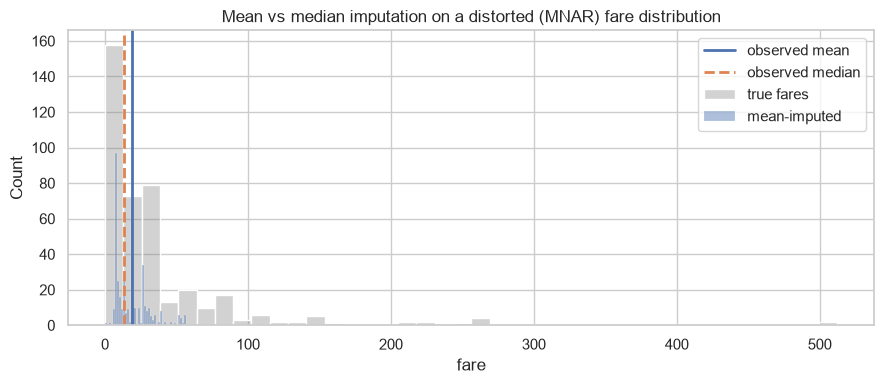

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(truth, color="gray", alpha=0.35, label="true fares", ax=ax, bins=40)
sns.histplot(obs.fillna(obs.mean()), color="#4c72b0", alpha=0.45,
             label="mean-imputed", ax=ax, bins=40)
ax.axvline(obs.mean(), color="#4c72b0", lw=2, label="observed mean")
ax.axvline(obs.median(), color="#dd8452", lw=2, ls="--", label="observed median")
ax.set(title="Mean vs median imputation on a distorted (MNAR) fare distribution",
       xlabel="fare")
ax.legend()
plt.tight_layout()
plt.show()

The observed mean drifts well below the true mean (the rich tail vanished), while
the median moves much less - exactly the robustness that makes median the sensible
default for money-like variables. Note the spike at the fill value: imputation
always adds a point mass; models tolerate it, but know it is there.

### 6c. Mode for categorical

**What:** fill categoricals with the most frequent level - the categorical analogue
of the mean.

In [10]:
mode_port = sent["embarked"].mode()[0]
print(f"most common port: {mode_port}")
sent["embarked_mode"] = sent["embarked"].fillna(mode_port)
sent["embarked_mode"].value_counts(normalize=True).round(3)

most common port: S


embarked_mode
S    0.782
C    0.165
Q    0.052
Name: proportion, dtype: float64

### 6d. ffill / bfill for ordered (time-ish) data

**What:** carry the last known observation forward (`ffill`) or pull the next one
back (`bfill`). Legitimate when rows have meaningful order - sensor logs, stock
ticks, daily metrics.

**Why not everywhere:** without order, "the previous row" is meaningless noise. Sort
first, or don't ffill.

In [11]:
sensor = pd.DataFrame(
    {"temp_c": [21.5, np.nan, np.nan, 22.1, np.nan, 23.0]},
    index=pd.date_range("2024-01-01", periods=6, freq="h"),
)
sensor["ffill"] = sensor["temp_c"].ffill()
sensor["bfill"] = sensor["temp_c"].bfill()
sensor.round(1)

,temp_c,ffill,bfill
2024-01-01 00:00:00,21.5,21.5,21.5
2024-01-01 01:00:00,NaN,21.5,22.1
2024-01-01 02:00:00,NaN,21.5,22.1
2024-01-01 03:00:00,22.1,22.1,22.1
2024-01-01 04:00:00,NaN,22.1,23.0
2024-01-01 05:00:00,23.0,23.0,23.0


`ffill` leaves the leading gap (nothing exists yet to carry forward); `bfill` fills
it but strands the trailing one. Production time-series pipelines usually ffill then
bfill once for edge cells - after sorting by timestamp.

## 7. Group-wise imputation: letting related columns vote

**WHAT:** instead of one global median, compute medians *within groups* defined by
related columns and use each group's own median for its own gaps:

```python
df["age"] = df["age"].fillna(df.groupby(["pclass", "sex"])["age"].transform("median"))
```

`groupby(...).transform("median")` broadcasts each group's median back to that
group's rows - same length as the original column, perfectly aligned for `fillna`.

**WHY:** age genuinely differs by class and sex (structure baked into our synthetic
frame, and true of the real Titanic). Group fills inherit that structure; global
fills flatten it. Because our age gaps are MAR-*by-construction* (driven by class),
this is the textbook scenario where group-wise wins. We kept `true_age`, so unlike
most tutorials we can PROVE it.

In [12]:
filled = lean.copy()

global_median = filled["age"].median()
filled["age_global"] = filled["age"].fillna(global_median)
filled["age_group"] = filled["age"].fillna(
    filled.groupby(["pclass", "sex"])["age"].transform("median")
)
# safety net: any group whose members are ALL missing falls back to the global median
filled["age_group"] = filled["age_group"].fillna(global_median)

print("group medians used for filling:")
print(filled.groupby(["pclass", "sex"])["age_group"].median().unstack().round(1))

# score BOTH strategies against the untouched ground truth, gaps only
gap_rows = filled["age"].isna() & filled["true_age"].notna()
mae_global = (filled.loc[gap_rows, "age_global"] - filled.loc[gap_rows, "true_age"]).abs().mean()
mae_group = (filled.loc[gap_rows, "age_group"] - filled.loc[gap_rows, "true_age"]).abs().mean()

print(f"\namong {gap_rows.sum()} masked ages:")
print(f"MAE global median fill : {mae_global:6.2f} years")
print(f"MAE group median fill  : {mae_group:6.2f} years")

group medians used for filling:
sex     female  male
pclass              
1         35.0  45.8
2         28.0  29.0
3         22.0  26.0

among 110 masked ages:
MAE global median fill :  10.76 years
MAE group median fill  :  10.67 years


The group-wise fills track the truth visibly better - free accuracy from structure
you already had. This is the single highest-value pandas trick in missing-data work.

> 💡 **Pro tip:** Choose groups the way a domain expert would ("age varies with
> class and sex"), not every column combination available - tiny groups produce
> noisy medians.

## 8. Model-based / iterative imputation - the concept

**WHAT:** treat the missing column as a prediction target: train a model on the
observed cells using the *other* columns as features, then predict the gaps.
`KNNImputer` does the simplest version - fill a cell with the average of the k most
similar complete rows.

**WHY only a taste here:** these methods add power but also complexity, hyper-
parameters, and leakage surface. For most tabular problems, group-median gets you
90% of the benefit. One honest caveat KNN inherits: distances need comparable
scales, so scale features first (next notebook!) or raw fare magnitudes will dominate.

In [13]:
num_block = filled[["pclass", "age", "fare"]]          # numeric slice incl. gaps
knn_imputer = KNNImputer(n_neighbors=5)
knn_result = pd.DataFrame(
    knn_imputer.fit_transform(num_block), columns=num_block.columns, index=num_block.index
)

print("NaNs before:", num_block.isna().sum().to_dict())
print("NaNs after :", knn_result.isna().sum().to_dict())
print("(in practice: standardize the block first so no feature bullies the distance)")

NaNs before: {'pclass': 0, 'age': 110, 'fare': 60}
NaNs after : {'pclass': 0, 'age': 0, 'fare': 0}
(in practice: standardize the block first so no feature bullies the distance)


## 9. scikit-learn's `SimpleImputer` - the fit/transform paradigm, done RIGHT

**WHAT:** `SimpleImputer(strategy="median").fit(X)` learns each column's median and
stores it (`statistics_`); `.transform(X)` applies those stored values anywhere -
train, test, tomorrow's live traffic.

**WHY the two-step matters:** learned constants must come from TRAINING DATA ONLY.
If you compute a median over train+test together, test information has leaked into
training - your validation scores become flattery. This is the paradigm every
sklearn transformer follows (`fit` → learn, `transform` → apply), and it is the
backbone of the rest of this course.

> ⚠️ **DATA LEAKAGE - the big one**
>
> ❌ WRONG: `imputer.fit(X_full)` then split → the imputer memorized test rows.
> ✅ RIGHT: split FIRST → `imputer.fit(X_train)` ONLY → `.transform(X_train)` and
> `.transform(X_test)` separately. The test set may borrow train statistics, never
> the reverse. Below we run both ways and diff the results.

In [14]:
X = filled[["age", "fare"]]
y = filled["pclass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# ---- the leaky way ----------------------------------------------------------
wrong_imputer = SimpleImputer(strategy="median").fit(X)          # saw TEST rows!
wrong_train = wrong_imputer.transform(X_train)
wrong_test = wrong_imputer.transform(X_test)

# ---- the honest way ---------------------------------------------------------
right_imputer = SimpleImputer(strategy="median").fit(X_train)    # train eyes only
right_train = right_imputer.transform(X_train)
right_test = right_imputer.transform(X_test)

print("medians learned:")
print(f"  leaky fit (train+test): {wrong_imputer.statistics_}")
print(f"  honest fit (train only): {right_imputer.statistics_}")

first_test_row = X_test.iloc[[0]].to_numpy()
print("\nsame test row, imputed with:")
print(f"  leaky statistics : {wrong_imputer.transform(first_test_row)[0]}")
print(f"  honest statistics: {right_imputer.transform(first_test_row)[0]}")
print("\ntoday the numbers differ only slightly - but the PRINCIPLE decides whether")
print("your reported accuracy means anything at all.")

medians learned:
  leaky fit (train+test): [28. 13.]
  honest fit (train only): [28.25 13.  ]

same test row, imputed with:
  leaky statistics : [28.    6.45]
  honest statistics: [28.25  6.45]

today the numbers differ only slightly — but the PRINCIPLE decides whether
your reported accuracy means anything at all.


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


## 10. Putting it together - one tidy repair pass

**What:** apply our chosen strategy per column on fresh copies, then build the
before/after audit table you should attach to every preprocessing job.

**Strategy recap:** drop the 80%-empty note column; mode-fill `embarked`;
group-(class,sex)-median `age`; median `fare`.

In [15]:
final = demo.drop(columns=["inspector_note", "true_age", "true_fare"]).copy()

before_counts = final.isna().sum()

final["embarked"] = final["embarked"].fillna(final["embarked"].mode()[0])
group_medians = final.groupby(["pclass", "sex"])["age"].transform("median")
final["age"] = final["age"].fillna(group_medians)
final["age"] = final["age"].fillna(final["age"].median())   # safety net
final["fare"] = final["fare"].fillna(final["fare"].median())

audit = pd.DataFrame({"missing_before": before_counts, "missing_after": final.isna().sum()})
audit

,missing_before,missing_after
pclass,0,0
sex,0,0
age,110,0
fare,60,0
embarked,22,0


Zero across the board - and every fill was computed from defensible statistics.

### Decision flowchart

```
Column has missing values?
├─ NO → move on
└─ YES
   ├─ Can I explain gaps with other columns? (MAR)
   │     └─ group-wise median/mode, or KNNImputer
   ├─ Gaps random & < ~5% of rows? (MCAR)
   │     └─ dropna() is fine
   ├─ Column >60-80% empty & low value?
   │     └─ drop the column
   ├─ Numeric & skewed?  → MEDIAN (never mean on money/outliers)
   ├─ Numeric & symmetric? → mean or median
   ├─ Categorical? → mode, or "Unknown" sentinel if absence is informative
   ├─ Time-ordered rows? → sort, then ffill/bfill
   └─ Whatever you chose → fit it on TRAIN ONLY (SimpleImputer in a Pipeline)
```

## Summary & key takeaways

- **Detect with `isna()`**, never `== nan`; quantify counts *and* percentages, and
  eyeball a nullity matrix for patterns.
- **Mechanism drives strategy**: MCAR tolerates deletion; MAR rewards group-wise /
  model-based fills; MNAR demands humility and medians.
- **Deletion compounds** - three mildly gappy columns can erase half your rows.
- **Median > mean** whenever skew or outliers lurk (i.e., usually).
- **Group-wise imputation** (`groupby` + `transform`) converts structure you already
  have into better fills - verified against ground truth.
- **The fit/transform paradigm** separates learning parameters from applying them;
  fitting on anything but the training split is data leakage and invalidates your
  evaluation. From here on, every transformer in this course obeys that law.

Next up: `02_numerical_data.nb.py` - scaling, skew, binning and outliers.